In [1]:
import numpy as np
import numdifftools as nd
from scipy import integrate, optimize, linalg
import matplotlib.pyplot as plt

In [2]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

https://stackoverflow.com/questions/79508027/graphing-nonlinear-systems-of-odes-in-python

In [3]:
K = 17.3
epsilon = 4.9
r = 2.7
mu = 0.9
gamma = 3.2  
alpha = 4 / (K - epsilon) ** 2  

In [4]:
p0 = (alpha, r, K, epsilon, mu, gamma)
p0

(0.02601456815816857, 2.7, 17.3, 4.9, 0.9, 3.2)

In [5]:
def model(t, y, alpha, r, K, epsilon, mu, gamma):
    return np.array([
        gamma * y[1] / (1 + y[1]) - mu * y[0],
        alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]
    ])

$$
\begin{align}
\frac{\mathrm{d}M}{\mathrm{d}t} &= \frac{\gamma N}{1 + N} - \mu M \\
\frac{\mathrm{d}N}{\mathrm{d}t} &= \alpha r \frac{N^2}{M + N} (K- N) (N - \epsilon) - \mu N
\end{align}
$$

In [6]:
Mlin = np.linspace(-10, 15, 1000)
Nlin = np.linspace(-5, 20, 1000)
M, N = np.meshgrid(Mlin, Nlin)

In [7]:
t = np.linspace(2, 10, 200)

In [8]:
U, V = model(t, [M, N], *p0)
C = np.sqrt(U ** 2 + V ** 2)

In [9]:
def proxy(x):
    return model(None, x, *p0)

In [10]:
sol0 = optimize.root(proxy, x0=[1, 1])
sol1 = optimize.root(proxy, x0=[5, 7.5])
sol2 = optimize.root(proxy, x0=[2.5, 17.5])
sol3 = optimize.root(proxy, x0=[13, -1.5])

/tmp/ipykernel_1864/4181885818.py:4: RuntimeWarning: invalid value encountered in scalar divide
  alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]


In [11]:
sol3

 message: The solution converged.
 success: True
  status: 1
     fun: [-1.389e-12 -7.772e-15]
       x: [ 1.366e+01 -1.352e+00]
  method: hybr
    nfev: 13
    fjac: [[-9.940e-01  1.098e-01]
           [-1.098e-01 -9.940e-01]]
       r: [ 9.011e-01 -2.558e+01 -4.092e+00]
     qtf: [ 7.022e-09  8.159e-10]

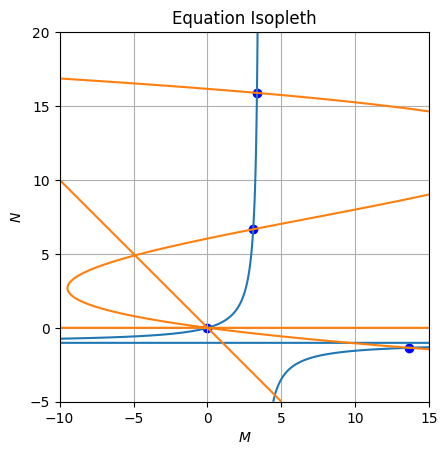

In [12]:
fig, axe = plt.subplots()
axe.contour(M, N, U, [0], colors=colors[0])
axe.contour(M, N, V, [0], colors=colors[1])
for sol in [sol0, sol1, sol2, sol3]:
    axe.scatter(*sol.x, color="blue")
axe.set_title("Equation Isopleth")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_aspect("equal")
axe.grid()

Text(0.5, 1.0, 'Vector Norm Field')

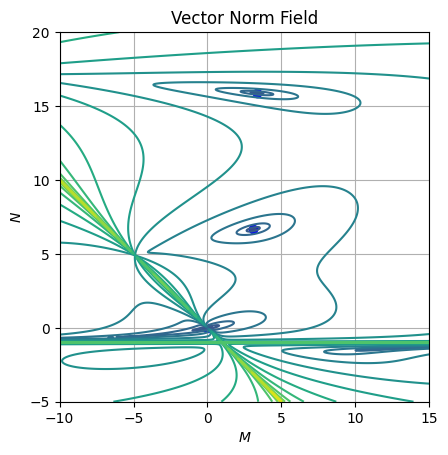

In [13]:
fig, axe = plt.subplots()
#axe.quiver(M[::50,::50], N[::50,::50], U[::50,::50], V[::50,::50], C[::50,::50])
axe.contour(M, N, np.log10(C), 20, cmap="viridis")
for sol in [sol0, sol1, sol2]:
    axe.scatter(*sol.x, color="blue")
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Vector Norm Field")

In [14]:
M0 = 5.6667
N0 = K / 1.5

In [15]:
y0 = (M0, N0)
y1 = (4, 6)
y2 = (10, 2.5)

In [16]:
ivp0 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y0, t_eval=t, atol=1e-8, rtol=1e-8)
ivp1 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y1, t_eval=t, atol=1e-8, rtol=1e-8)
ivp2 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y2, t_eval=t, atol=1e-8, rtol=1e-8)

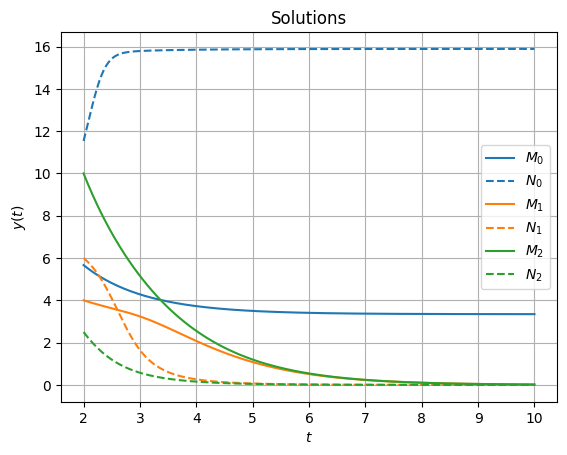

In [17]:
fig, axe = plt.subplots()
for ivp, color in zip([ivp0, ivp1, ivp2], colors[:3]):
    axe.plot(t, ivp.y[0], "-", color=color)
    axe.plot(t, ivp.y[1], "--", color=color)
axe.grid()
axe.set_title("Solutions")
axe.set_xlabel("$t$")
axe.set_ylabel("$y(t)$")
axe.legend(["$M_0$", "$N_0$", "$M_1$", "$N_1$", "$M_2$", "$N_2$"])
#axe.set_ylim([15.8, 16])
#axe.set_ylim([-0.1, 0.1])
#axe.set_ylim([3.3, 3.4])

Text(0.5, 1.0, 'Phase diagram')

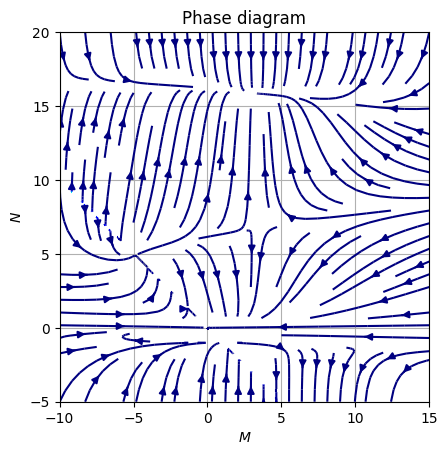

In [29]:
fig, axe = plt.subplots()
axe.streamplot(M, N, U, V, color=C, cmap="jet")
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")

Text(0.5, 1.0, 'Phase diagram')

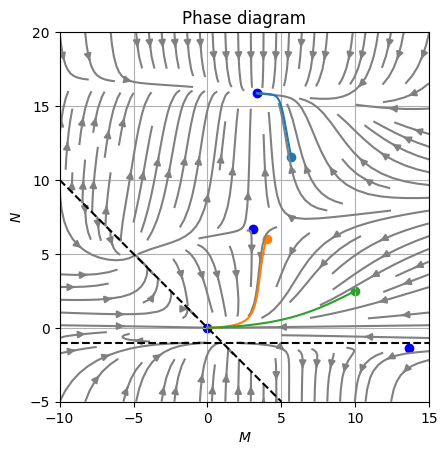

In [19]:
fig, axe = plt.subplots()
axe.streamplot(M, N, U, V, color="grey")
for sol in [sol0, sol1, sol2, sol3]:
    axe.scatter(*sol.x, marker="o", color="blue")
axe.plot([-10, 5], [10, -5], "--", color="black")
axe.plot([-10, 15], [-1, -1], "--", color="black")
for y, ivp, color in zip([y0, y1, y2], [ivp0, ivp1, ivp2], colors[:3]):
    axe.scatter(*y, color=color)
    axe.plot(*ivp.y, color=color)
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")

In [20]:
eigenvalues = []
for sol in [sol0, sol1, sol2, sol3]:
    J = nd.Jacobian(proxy)(sol.x)
    e, v = linalg.eigh(J)
    eigenvalues.append(e)

In [21]:
eigenvalues

[array([-6.85418835, -0.9       ]),
 array([-0.9918713 ,  3.21386104]),
 array([-8.74288298, -0.82952149]),
 array([-0.90452072,  1.26327589])]